In [ ]:
#Project 1(Supervised Learning)

In [ ]:
#preprocessing in report project 1//use this first,ignore bottom preprocessing codes
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Step 1: Load the dataset
from google.colab import files
uploaded = files.upload()

df=pd.read_csv("heart.csv")


# Step 2: Check for missing values
print("Missing values:\n", df.isnull().sum())

# Step 3: Encode categorical columns if needed
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Step 4: Separate features and target
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Step 5: Normalize numerical features for KNN
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Step 6: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Step 7: Output shapes
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Saving heart.csv to heart.csv
Missing values:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
Training data shape: (642, 11)
Testing data shape: (276, 11)


In [ ]:
#KNN

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [ ]:
# Load data
h=pd.read_csv("heart.csv")

# Print data
print(h)

     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0     40   M           ATA        140          289          0     Normal   
1     49   F           NAP        160          180          0     Normal   
2     37   M           ATA        130          283          0         ST   
3     48   F           ASY        138          214          0     Normal   
4     54   M           NAP        150          195          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144          193          1     Normal   
915   57   M           ASY        130          131          0     Normal   
916   57   F           ATA        130          236          0        LVH   
917   38   M           NAP        138          175          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0      172              N  

In [ ]:
print(h.shape)                # Check rows and columns
print()
print(h.columns)              # List of column names
print()
print(h.info())               # Data types and non-null values
print()
print(h.describe())           # Summary statistics
print()
print(h.isnull().sum())       # Check for missing values

(918, 12)

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.

In [ ]:
# Encode categorical variables
h = pd.get_dummies(h, drop_first=True)

In [ ]:
# Split features and target
X = h.drop("HeartDisease", axis=1)
y = h["HeartDisease"]

In [ ]:
# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print(confusion_matrix(y_test, y_pred_knn))
print()
print(classification_report(y_test, y_pred_knn))
print()
print("Accuracy:", accuracy_score(y_test, y_pred_knn))


[[ 99  13]
 [ 23 141]]

              precision    recall  f1-score   support

           0       0.81      0.88      0.85       112
           1       0.92      0.86      0.89       164

    accuracy                           0.87       276
   macro avg       0.86      0.87      0.87       276
weighted avg       0.87      0.87      0.87       276


Accuracy: 0.8695652173913043


In [ ]:
#Naive Bayers

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print(confusion_matrix(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))


[[ 99  13]
 [ 21 143]]
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       112
           1       0.92      0.87      0.89       164

    accuracy                           0.88       276
   macro avg       0.87      0.88      0.87       276
weighted avg       0.88      0.88      0.88       276

Accuracy: 0.8768115942028986


In [ ]:
#logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Train logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)

# Confusion matrix and evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print()
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print()
print("Accuracy:", accuracy_score(y_test, y_pred))


Confusion Matrix:
 [[ 99  13]
 [ 20 144]]


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.86       112
           1       0.92      0.88      0.90       164

    accuracy                           0.88       276
   macro avg       0.87      0.88      0.88       276
weighted avg       0.88      0.88      0.88       276


Accuracy: 0.8804347826086957


In [ ]:
#Project 2(Unsupervised Learning)

In [ ]:
#k means(maybe need to choose another dataset,and see what insights to get from dataset)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ObesityDataSet_raw_and_data_sinthetic.csv to ObesityDataSet_raw_and_data_sinthetic.csv


In [ ]:
# Load data
o=pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

# Print data
print(o)

      Gender        Age    Height      Weight family_history_with_overweight  \
0     Female  21.000000  1.620000   64.000000                            yes   
1     Female  21.000000  1.520000   56.000000                            yes   
2       Male  23.000000  1.800000   77.000000                            yes   
3       Male  27.000000  1.800000   87.000000                             no   
4       Male  22.000000  1.780000   89.800000                             no   
...      ...        ...       ...         ...                            ...   
2106  Female  20.976842  1.710730  131.408528                            yes   
2107  Female  21.982942  1.748584  133.742943                            yes   
2108  Female  22.524036  1.752206  133.689352                            yes   
2109  Female  24.361936  1.739450  133.346641                            yes   
2110  Female  23.664709  1.738836  133.472641                            yes   

     FAVC  FCVC  NCP       CAEC SMOKE  

In [ ]:
print(o.shape)                # Check rows and columns
print()
print(o.columns)              # List of column names
print()
print(o.info())               # Data types and non-null values
print()
print(o.describe())           # Summary statistics
print()
print(o.isnull().sum())

(2111, 17)

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   o

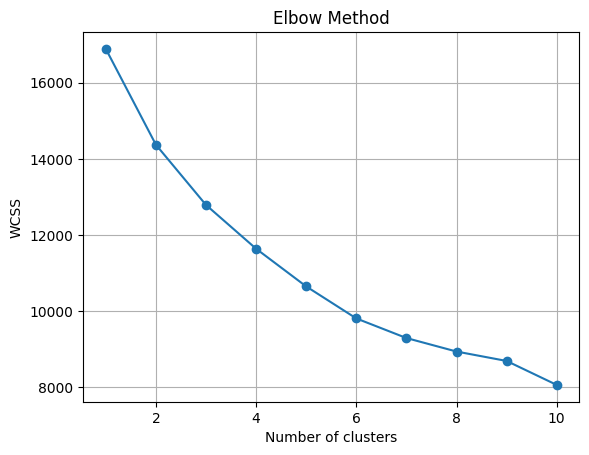

[[-0.57215414 -0.62633476 -0.77029894 -0.30045345 -0.3689596  -0.30664877
  -0.18842287  0.28766334]
 [-0.1790102   0.91731959  0.57748741  0.08317365  0.30095022  0.43269563
   0.6201739   0.11044324]
 [ 1.08978676 -0.41120813  0.2877821   0.31697177  0.10276391 -0.17766799
  -0.61970221 -0.57737063]]

Cluster
0    787
1    782
2    542
Name: count, dtype: int64



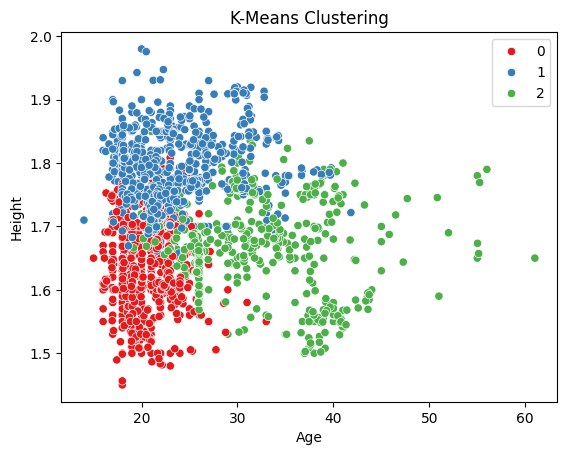

In [ ]:
numerical_o = o.select_dtypes(include=[np.number])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_o)

wcss = []  # Within-cluster sum of squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)
numerical_o['Cluster'] = clusters

# Cluster centers
print(kmeans.cluster_centers_)
print()

# Check how many data points in each cluster
print(numerical_o['Cluster'].value_counts())
print()

# Optional: visualize with 2 features
sns.scatterplot(x=numerical_o.iloc[:, 0], y=numerical_o.iloc[:, 1], hue=numerical_o['Cluster'], palette='Set1')
plt.legend(loc='upper right')
plt.title("K-Means Clustering")
plt.show()